# Desafio 1 — Perceptron Multicamadas em PyTorch

Este notebook usa redes neurais para resolver dois problemas: indicar a probabilidade de uma pessoa ter diabetes e estimar o preço de um imóvel. O processo foi organizado para que os resultados possam ser reproduzidos.

## 1. Ambiente

Esta parte reúne as ferramentas que serão usadas ao longo do notebook. Os nomes das bibliotecas são mantidos como elas os definem.

### Bloco: importação de bibliotecas

**O que faz.** Carrega as bibliotecas usadas no notebook. Elas ajudam a ler os arquivos, organizar os dados, criar gráficos, treinar modelos e avaliar os resultados.

**Como faz.** Cada biblioteca é importada uma vez, no início. O nome `grafico` é apenas um atalho em português para a parte do `matplotlib` que desenha gráficos.


In [1]:
# Importa somente as bibliotecas necessárias ao fluxo.
# Manipulacao portatil de caminhos de arquivos.
from pathlib import Path
from time import perf_counter
# Gerador pseudoaleatorio usado pelo embaralhamento do treino.
import random

# Geracao de graficos com API do pyplot.
import matplotlib.pyplot as grafico
# Computacao numerica vetorial.
import numpy
# Leitura e manipulacao de tabelas (DataFrame).
import pandas
# Apenas para consultar a versao no log.
import sklearn
# Backend de deep learning (tensores e autodiff).
import torch
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter

### Bloco: constantes e caminhos globais

**O que faz.** Reúne em um só lugar as configurações do notebook: como os dados serão divididos, quantas vezes a rede será treinada, o tamanho dos grupos de dados e onde os arquivos serão salvos.

**Como faz.** Os percentuais de treino, validação e teste são calculados a partir de dois valores principais. O código também cria as pastas usadas para guardar os resultados. Os arquivos CSV com os dados precisam estar nos caminhos informados.


In [2]:
# Centraliza números e textos com significado para evitar valores mágicos no fluxo.
# Semente unica para garantir reprodutibilidade total.
SEMENTE_GLOBAL = 42
# 15% dos dados vao para validacao.
PROPORCAO_VALIDACAO = 0.15
# 15% dos dados vao para teste final.
PROPORCAO_TESTE = 0.15
# Reserva = validacao + teste.
PROPORCAO_RESERVA = PROPORCAO_VALIDACAO + PROPORCAO_TESTE
# Fracao da reserva que vai para teste.
PROPORCAO_TESTE_NA_RESERVA = PROPORCAO_TESTE / PROPORCAO_RESERVA

# Lote grande: dataset de diabetes tem muitos exemplos.
TAMANHO_LOTE_DIABETES = 16
# Lote menor: dataset de imoveis e menor.
TAMANHO_LOTE_IMOVEIS = 16
# Zero processos evita conflitos no Windows.
NUMERO_PROCESSOS = 0
# Duas camadas ocultas: 32 e depois 16 neuronios.
QUANTIDADES_NEURONIOS_OCULTOS = (32, 16)
# Saida escalar (logito ou preco).
QUANTIDADE_SAIDAS = 1

# Limite de epocas para cada experimento.
EPOCAS_PADRAO = 40
# Valor inicial usado pelo Adam.
TAXA_APRENDIZADO_INICIAL = 1e-3
# Piso do scheduler antes de interromper.
TAXA_APRENDIZADO_MINIMA = 1e-5
# Multiplicador aplicado quando a validacao estagna.
FATOR_REDUCAO_TAXA_APRENDIZADO = 0.5
# Epocas sem melhora para reduzir a LR.
PACIENCIA_AGENDADOR_TAXA_APRENDIZADO = 3
# Melhoria minima para resetar a paciencia do scheduler.
MELHORIA_MINIMA_AGENDADOR = 1e-3
# Epocas sem melhora para interromper o treino.
PACIENCIA_PARADA_ANTECIPADA = 8
# Melhoria minima para resetar a paciencia.
MELHORIA_MINIMA_PARADA_ANTECIPADA = 1e-4
# Penalizacao L2 aplicada pelo otimizador.
DECAIMENTO_PESOS = 1e-2

# Limiar padrao de classificacao binaria.
LIMIAR_DECISAO_INICIAL = 0.5
# Limite inferior da busca em grade.
LIMIAR_DECISAO_INFERIOR = 0.10
# Limite superior da busca em grade.
LIMIAR_DECISAO_SUPERIOR = 0.90
# Resolucao da busca em grade.
PASSO_BUSCA_LIMIAR = 0.01
# Saturacao numerica maxima aceita no logito.
LIMITE_ABSOLUTO_LOGITO = 50.0
# Norma a partir da qual o gradiente e considerado explosivo.
LIMIAR_GRADIENTE_EXPLOSAO = 100.0
# Fator usado em testes de piora da validacao.
FATOR_PIORA_VALIDACAO = 1.10
# Queda minima relativa da perda.
FATOR_REDUCAO_MINIMA_PERDA = 0.95

# Largura x altura em polegadas do painel de diagnostico.
TAMANHO_FIGURA_DIAGNOSTICO = (15, 4)
# Tamanho do grafico da matriz de confusao.
TAMANHO_FIGURA_MATRIZ = (5, 4)
# Tamanho do grafico de regressao.
TAMANHO_FIGURA_REGRESSAO = (12, 4)
# Alfa das linhas de grade.
TRANSPARENCIA_GRADE = 0.3
# Bins do histograma de residuos.
QUANTIDADE_INTERVALOS_HISTOGRAMA = 20
# Problema binario (diabetico / nao diabetico).
QUANTIDADE_CLASSES_DIABETES = 2
# max_iter da regressao logistica de referencia.
ITERACOES_MAXIMAS_MODELO_REFERENCIA = 1000

# Identificador da ReLU nas configuracoes.
ATIVACAO_RETIFICADA = 'retificada'
# Identificador da LeakyReLU.
ATIVACAO_RETIFICADA_COM_VAZAMENTO = 'retificada_com_vazamento'
# Inicializacao default do PyTorch.
INICIALIZACAO_PADRAO = 'padrao'
# Inicializacao Kaiming He para ReLU.
INICIALIZACAO_KAIMING = 'kaiming'
# Roteamento interno para o problema de classificacao.
NOME_PROBLEMA_DIABETES = 'diabetes'
# Roteamento interno para o problema de regressao.
NOME_PROBLEMA_IMOVEIS = 'preco_imoveis'

# Diretorio atual de execucao do notebook.
PASTA_RAIZ_PROJETO = Path.cwd()
# Dados versionados no diretorio datasets do projeto.
PASTA_DADOS = PASTA_RAIZ_PROJETO / 'datasets'
CAMINHO_TABELA_DIABETES = PASTA_DADOS / 'diabetes_prediction_dataset.csv'
CAMINHO_TABELA_IMOVEIS = PASTA_DADOS / 'house_price_regression_dataset.csv'
PASTA_CHECKPOINTS = PASTA_RAIZ_PROJETO / 'checkpoints'
PASTA_EXECUCOES_TENSORBOARD = PASTA_RAIZ_PROJETO / 'runs'

# Cria a pasta se ainda nao existir.
PASTA_CHECKPOINTS.mkdir(exist_ok=True)
# Cria a pasta de runs se ainda nao existir.
PASTA_EXECUCOES_TENSORBOARD.mkdir(exist_ok=True)

### Bloco: fixar aleatoriedade e configurar dispositivo

**O que faz.** Faz com que o notebook repita o mesmo sorteio dos dados e comece a rede do mesmo ponto sempre que for executado nas mesmas condições. Também escolhe automaticamente entre usar a GPU, se houver uma disponível, ou a CPU.

**Como faz.** A função `fixar_aleatoriedade` define uma mesma semente para os sorteios feitos pelas bibliotecas. Depois, o código verifica se a GPU pode ser usada e confirma que os dois arquivos de dados existem. Se algum arquivo estiver faltando, a execução para e informa o caminho esperado.


In [3]:
# Fixa todas as fontes de aleatoriedade para reproduzir divisões, lotes e pesos.
def fixar_aleatoriedade(semente=SEMENTE_GLOBAL):
    random.seed(semente)
    numpy.random.seed(semente)
    torch.manual_seed(semente)
    torch.cuda.manual_seed_all(semente)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


fixar_aleatoriedade()
# GPU se houver, senao CPU.
DISPOSITIVO = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Aguarda operacoes CUDA antes de medir intervalos de execucao.
def sincronizar_dispositivo_para_medicao(dispositivo):
    if dispositivo.type == 'cuda':
        torch.cuda.synchronize(dispositivo)


print(f'Dispositivo: {DISPOSITIVO}')
# Versoes no log ajudam a diagnosticar diferencas entre ambientes.
print(f'PyTorch: {torch.__version__} | scikit-learn: {sklearn.__version__}')
assert CAMINHO_TABELA_DIABETES.exists(), f'Arquivo não encontrado: {CAMINHO_TABELA_DIABETES}'
assert CAMINHO_TABELA_IMOVEIS.exists(), f'Arquivo não encontrado: {CAMINHO_TABELA_IMOVEIS}'

Dispositivo: cuda
PyTorch: 2.13.0+cu130 | scikit-learn: 1.9.0


### Bloco: teste rápido do TensorBoard

**O que faz.** Faz um teste rápido, também chamado de *smoke test*, para confirmar que o TensorBoard está funcionando. O TensorBoard é uma página que mostra, em gráficos, o que acontece durante o treinamento da rede.

**Como faz.** O `SummaryWriter` grava um único valor simples em uma pasta de teste. Se esse arquivo for criado, o TensorBoard poderá ler os registros do treinamento depois. Ao final, o notebook mostra o comando que abre o painel no navegador.


In [4]:
# Registra um único evento para confirmar o TensorBoard antes do treinamento.
escritor_verificacao = SummaryWriter(PASTA_EXECUCOES_TENSORBOARD / 'verificacao_ambiente')
escritor_verificacao.add_scalar('ambiente/verificacao', 1, 0)
escritor_verificacao.close()
print(f'Abra o TensorBoard com: tensorboard --logdir {PASTA_EXECUCOES_TENSORBOARD}')

Abra o TensorBoard com: tensorboard --logdir c:\Users\lord_\OneDrive\Área de Trabalho\projeto-v2\runs


## 2. Utilitários de dados e métricas

As funções abaixo cuidam de tarefas que serão repetidas durante o treinamento: separar os dados em grupos, acompanhar o ajuste da rede e calcular resultados.

### Bloco: utilitários de dados e gradientes

**O que faz.** Cria grupos menores de dados para o treinamento e mede o tamanho dos ajustes calculados pela rede. Esses grupos menores são chamados de lotes.

**Como faz.** A função `criar_carregador` transforma os dados em lotes e embaralha somente os lotes de treino. A função `calcular_norma_global_gradientes` resume, em um número, o tamanho das correções sugeridas para os pesos da rede. Valores muito altos podem indicar treinamento instável.


In [5]:
# Cria lotes reproduzíveis e seguros no Windows.
def criar_carregador(caracteristicas, rotulos, tamanho_lote, embaralhar):
    conjunto_tensores = TensorDataset(
        torch.tensor(caracteristicas, dtype=torch.float32),
        torch.tensor(rotulos, dtype=torch.float32),
    )
    # Gerador proprio do DataLoader para nao depender do estado global.
    gerador_aleatorio = torch.Generator().manual_seed(SEMENTE_GLOBAL)
    return DataLoader(
        conjunto_tensores,
        batch_size=tamanho_lote,
        shuffle=embaralhar,
        generator=gerador_aleatorio,
        # Mantem em 0 para evitar travas no Windows.
        num_workers=NUMERO_PROCESSOS,
    )


# Calcula uma única norma global a partir dos gradientes de todos os parâmetros.
def calcular_norma_global_gradientes(modelo):
    quadrados_normas = []
    for parametro in modelo.parameters():
        if parametro.grad is not None:
            quadrados_normas.append(parametro.grad.detach().norm(2).item() ** 2)
    return float(numpy.sqrt(sum(quadrados_normas))) if quadrados_normas else 0.0

### Bloco: métricas e busca de limiar

**O que faz.** Calcula os resultados dos dois problemas. Para diabetes, mostra acurácia, precisão, sensibilidade e F1; para imóveis, mostra o erro médio e o quanto as previsões explicam os preços reais. Também procura o melhor ponto de corte para transformar probabilidades de diabetes em “sim” ou “não”.

**Como faz.** Na classificação, a saída da rede é convertida em uma probabilidade entre 0 e 1. Na regressão, os preços previstos voltam à unidade monetária original antes de serem comparados aos preços reais. O ponto de corte é escolhido somente com os dados de validação; os dados de teste ficam reservados para a avaliação final.


In [6]:
# Calcula métricas de classificação a partir das saídas sem ativação da rede.
def calcular_metricas_classificacao(rotulos_reais, valores_saida, limiar_decisao=LIMIAR_DECISAO_INICIAL):
    valores_limitados = numpy.clip(
        valores_saida.ravel(),
        -LIMITE_ABSOLUTO_LOGITO,
        LIMITE_ABSOLUTO_LOGITO,
    )
    probabilidades = 1 / (1 + numpy.exp(-valores_limitados))
    classes_previstas = (probabilidades >= limiar_decisao).astype(int)
    classes_reais = rotulos_reais.ravel().astype(int)
    return {
        'acuracia': accuracy_score(classes_reais, classes_previstas),
        'precisao': precision_score(classes_reais, classes_previstas, zero_division=0),
        'sensibilidade': recall_score(classes_reais, classes_previstas, zero_division=0),
        'media_harmonica_precisao_sensibilidade': f1_score(
            classes_reais,
            classes_previstas,
            zero_division=0,
        ),
    }


# Restaura preços para a unidade monetária antes de calcular métricas de regressão.
def calcular_metricas_regressao(rotulos_normalizados, previsoes_normalizadas, normalizador_alvo):
    precos_reais = normalizador_alvo.inverse_transform(rotulos_normalizados.reshape(-1, 1)).ravel()
    precos_previstos = normalizador_alvo.inverse_transform(previsoes_normalizadas.reshape(-1, 1)).ravel()
    return {
        'erro_absoluto_medio': mean_absolute_error(precos_reais, precos_previstos),
        'raiz_erro_quadratico_medio': mean_squared_error(precos_reais, precos_previstos) ** 0.5,
        'coeficiente_determinacao': r2_score(precos_reais, precos_previstos),
    }


# Escolhe o limiar somente com a validação, evitando usar o conjunto de teste na decisão.
def encontrar_melhor_limiar_classificacao(rotulos_reais, valores_saida):
    limites_busca = numpy.arange(
        LIMIAR_DECISAO_INFERIOR,
        LIMIAR_DECISAO_SUPERIOR + PASSO_BUSCA_LIMIAR,
        PASSO_BUSCA_LIMIAR,
    )
    pontuacoes = []
    for limiar_candidato in limites_busca:
        metricas_candidato = calcular_metricas_classificacao(
            rotulos_reais,
            valores_saida,
            limiar_candidato,
        )
        pontuacoes.append(metricas_candidato['media_harmonica_precisao_sensibilidade'])
    posicao_melhor_limiar = int(numpy.argmax(pontuacoes))
    return float(limites_busca[posicao_melhor_limiar])

### Bloco: matriz de confusao no TensorBoard

**O que faz.** Transforma a matriz de confusao da validacao em uma imagem para consulta no TensorBoard.

**Como faz.** A figura do matplotlib e renderizada em RGB, reorganizada para o formato `[C, H, W]` esperado pelo PyTorch e registrada como imagem.

In [7]:
# Calcula a matriz com classes explicitas para sempre preservar as quatro celulas.
def calcular_matriz_confusao_classificacao(rotulos_reais, valores_saida, limiar_decisao):
    valores_limitados = numpy.clip(valores_saida.ravel(), -LIMITE_ABSOLUTO_LOGITO, LIMITE_ABSOLUTO_LOGITO)
    probabilidades = 1 / (1 + numpy.exp(-valores_limitados))
    classes_previstas = (probabilidades >= limiar_decisao).astype(int)
    classes_reais = rotulos_reais.ravel().astype(int)
    return confusion_matrix(classes_reais, classes_previstas, labels=[0, 1])


# Desenha uma figura autoexplicativa a partir da matriz numerica.
def criar_figura_matriz_confusao(matriz_confusao, titulo):
    figura, eixo = grafico.subplots(figsize=TAMANHO_FIGURA_MATRIZ)
    imagem = eixo.imshow(matriz_confusao, cmap='Blues')
    figura.colorbar(imagem, ax=eixo, label='Quantidade de exemplos')
    eixo.set(
        title=titulo,
        xlabel='Previsto',
        ylabel='Real',
        xticks=[0, 1],
        yticks=[0, 1],
        xticklabels=['Nao diabetes', 'Diabetes'],
        yticklabels=['Nao diabetes', 'Diabetes'],
    )
    for linha, coluna in numpy.ndindex(matriz_confusao.shape):
        eixo.text(coluna, linha, str(matriz_confusao[linha, coluna]), ha='center', va='center')
    figura.tight_layout()
    return figura


# Converte a figura renderizada em tensor RGB no formato [C, H, W].
def converter_figura_para_tensor_imagem(figura):
    figura.canvas.draw()
    imagem_rgb = numpy.asarray(figura.canvas.buffer_rgba())[:, :, :3].copy()
    return torch.from_numpy(imagem_rgb).permute(2, 0, 1)


# Registra uma unica matriz de validacao para o melhor checkpoint do experimento.
def registrar_matriz_confusao_tensorboard(
    escritor_tensorboard, rotulos_reais, valores_saida, limiar_decisao, numero_epoca, nome_experimento,
):
    matriz_confusao = calcular_matriz_confusao_classificacao(
        rotulos_reais, valores_saida, limiar_decisao,
    )
    figura = criar_figura_matriz_confusao(
        matriz_confusao, f'Matriz de confusao - {nome_experimento}',
    )
    imagem_tensor = converter_figura_para_tensor_imagem(figura)
    escritor_tensorboard.add_image(
        'classificacao/matriz_confusao_validacao', imagem_tensor, numero_epoca,
    )
    grafico.close(figura)

## 3. Modelo e execução de épocas

A rede tem duas camadas internas pequenas. As etapas de treino e avaliação são separadas para facilitar a leitura e a conferência dos resultados.

### Bloco: classe PerceptronMulticamadas

**O que faz.** Cria a rede neural usada nos dois problemas. Ela recebe os dados de entrada, passa por duas camadas internas e devolve uma única resposta: uma pontuação para diabetes ou um preço estimado para imóveis.

**Como faz.** A função monta as camadas conforme a configuração do experimento. Ela pode usar ReLU ou LeakyReLU, que são formas de a rede aprender relações não lineares. Também pode incluir normalização em lote, que ajuda a estabilizar o treinamento, e dropout, que desliga parte dos neurônios temporariamente para reduzir sobreajuste.


In [8]:
# Implementa explicitamente o Perceptron Multicamadas solicitado pelo desafio.
class PerceptronMulticamadas(nn.Module):
    def __init__(
        proprio,
        quantidade_entradas,
        quantidade_saidas,
        tipo_ativacao=ATIVACAO_RETIFICADA,
        usar_normalizacao_lote=False,
        taxa_descarte=0.0,
        tipo_inicializacao=INICIALIZACAO_PADRAO,
    ):
        # Inicializa a classe base nn.Module.
        super().__init__()
        classe_ativacao = (
            nn.ReLU
            if tipo_ativacao == ATIVACAO_RETIFICADA
            else nn.LeakyReLU
        )
        # Lista onde as camadas serao empilhadas dinamicamente.
        camadas = []
        # Controla a dimensionalidade da proxima camada.
        quantidade_entradas_camada = quantidade_entradas
        for quantidade_neuronios in QUANTIDADES_NEURONIOS_OCULTOS:
            camadas.append(nn.Linear(quantidade_entradas_camada, quantidade_neuronios))
            # BatchNorm estabiliza ativacoes intermediarias.
            if usar_normalizacao_lote:
                camadas.append(nn.BatchNorm1d(quantidade_neuronios))
            camadas.append(classe_ativacao())
            # Dropout so faz sentido quando ha risco de sobreajuste.
            if taxa_descarte > 0.0:
                camadas.append(nn.Dropout(taxa_descarte))
            quantidade_entradas_camada = quantidade_neuronios
        camadas.append(nn.Linear(quantidade_entradas_camada, quantidade_saidas))
        # Encapsula a sequencia em um unico modulo reaproveitavel.
        proprio.rede = nn.Sequential(*camadas)
        if tipo_inicializacao == INICIALIZACAO_KAIMING:
            proprio._aplicar_inicializacao_kaiming()

    def _aplicar_inicializacao_kaiming(proprio):
        for camada in proprio.modules():
            if isinstance(camada, nn.Linear):
                nn.init.kaiming_normal_(camada.weight, nonlinearity='relu')
                nn.init.zeros_(camada.bias)

    def forward(proprio, caracteristicas):
        return proprio.rede(caracteristicas)

### Bloco: época de treino e época de validação

**O que faz.** Executa uma época de treino e uma época de validação. Uma época é uma passagem por todos os dados de treino. No treino, a rede aprende; na validação, ela apenas é medida, sem alterar seus pesos.

**Como faz.** Os dados são processados em lotes. Em cada lote de treino, o modelo calcula o erro, descobre como corrigir seus pesos e aplica a correção. A validação usa dados separados e registra o erro sem aprender com eles. O notebook também acompanha o tamanho das correções para ajudar a identificar instabilidade.


In [9]:
# Executa somente atualização de pesos e coleta evidências do treinamento.
def executar_epoca_treino(modelo, carregador_treino, criterio, otimizador):
    # Habilita Dropout/BN em modo treino.
    modelo.train()
    perdas_ponderadas = []
    rotulos_epoca = []
    saidas_epoca = []
    normas_gradientes = []
    for lote_caracteristicas, lote_rotulos in carregador_treino:
        lote_caracteristicas = lote_caracteristicas.to(DISPOSITIVO)
        lote_rotulos = lote_rotulos.to(DISPOSITIVO)
        # Zera gradientes antes do novo backward.
        otimizador.zero_grad()
        valores_saida = modelo(lote_caracteristicas)
        perda = criterio(valores_saida, lote_rotulos)
        # Calcula gradientes via autodiff.
        perda.backward()
        normas_gradientes.append(calcular_norma_global_gradientes(modelo))
        # Atualiza os pesos com os gradientes calculados.
        otimizador.step()
        perdas_ponderadas.append(perda.item() * len(lote_caracteristicas))
        rotulos_epoca.append(lote_rotulos.detach().cpu().numpy())
        saidas_epoca.append(valores_saida.detach().cpu().numpy())
    return {
        'perda_media': sum(perdas_ponderadas) / len(carregador_treino.dataset),
        'rotulos': numpy.vstack(rotulos_epoca),
        'valores_saida': numpy.vstack(saidas_epoca),
        'norma_gradientes_media': float(numpy.mean(normas_gradientes)),
        'norma_gradientes_maxima': float(numpy.max(normas_gradientes)),
    }


# Executa somente validação, sem construir gradientes ou alterar pesos.
def executar_epoca_validacao(modelo, carregador_validacao, criterio):
    # Desativa Dropout/BN para avaliacao estavel.
    modelo.eval()
    perdas_ponderadas = []
    rotulos_epoca = []
    saidas_epoca = []
    # Desliga o grafo de computacao para economizar memoria.
    with torch.no_grad():
        for lote_caracteristicas, lote_rotulos in carregador_validacao:
            lote_caracteristicas = lote_caracteristicas.to(DISPOSITIVO)
            lote_rotulos = lote_rotulos.to(DISPOSITIVO)
            valores_saida = modelo(lote_caracteristicas)
            perda = criterio(valores_saida, lote_rotulos)
            perdas_ponderadas.append(perda.item() * len(lote_caracteristicas))
            rotulos_epoca.append(lote_rotulos.cpu().numpy())
            saidas_epoca.append(valores_saida.cpu().numpy())
    return {
        'perda_media': sum(perdas_ponderadas) / len(carregador_validacao.dataset),
        'rotulos': numpy.vstack(rotulos_epoca),
        'valores_saida': numpy.vstack(saidas_epoca),
    }

## 4. Preparação dos dados

Os dados são divididos antes de qualquer preparo. Assim, a validação e o teste não influenciam o que o modelo aprende no treino.

### Bloco: separação treino/validação/teste

**O que faz.** Separa os dados em três partes: treino, validação e teste. O treino ensina o modelo, a validação ajuda a escolher a melhor configuração e o teste mostra o resultado final.

**Como faz.** A divisão usa a mesma semente para poder ser repetida. No problema de diabetes, ela também preserva aproximadamente a proporção entre pessoas com e sem diabetes em cada parte dos dados.


In [10]:
# Produz as três partições com proporções fixas e estratificação opcional.
def separar_treino_validacao_teste(caracteristicas, rotulos, estratificar):
    # Stratify exige rotulos para manter a proporcao das classes.
    rotulos_estratificacao = rotulos if estratificar else None
    # Primeira divisao: separa treino da reserva (validacao+teste).
    caracteristicas_treino, caracteristicas_reserva, rotulos_treino, rotulos_reserva = train_test_split(
        caracteristicas,
        rotulos,
        test_size=PROPORCAO_RESERVA,
        stratify=rotulos_estratificacao,
        random_state=SEMENTE_GLOBAL,
    )
    estratificacao_reserva = rotulos_reserva if estratificar else None
    # Segunda divisao: reparte a reserva em validacao e teste.
    caracteristicas_validacao, caracteristicas_teste, rotulos_validacao, rotulos_teste = train_test_split(
        caracteristicas_reserva,
        rotulos_reserva,
        test_size=PROPORCAO_TESTE_NA_RESERVA,
        stratify=estratificacao_reserva,
        random_state=SEMENTE_GLOBAL,
    )
    return {
        'caracteristicas_treino': caracteristicas_treino,
        'caracteristicas_validacao': caracteristicas_validacao,
        'caracteristicas_teste': caracteristicas_teste,
        'rotulos_treino': rotulos_treino,
        'rotulos_validacao': rotulos_validacao,
        'rotulos_teste': rotulos_teste,
    }

### Bloco: carregadores por partição e transformador de diabetes

**O que faz.** Prepara os dados de diabetes para serem entregues à rede em lotes e define como cada coluna será tratada antes do treino.

**Como faz.** O treino é embaralhado; validação e teste mantêm a mesma ordem. Os valores numéricos são colocados em uma escala parecida, e as informações por categoria, como gênero e histórico de tabagismo, são transformadas em colunas numéricas que a rede consegue usar.


In [11]:
# Centraliza a criação dos três carregadores para evitar repetição entre problemas.
def criar_carregadores_particoes(
    caracteristicas_treino,
    caracteristicas_validacao,
    caracteristicas_teste,
    rotulos_treino,
    rotulos_validacao,
    rotulos_teste,
    tamanho_lote,
):
    # Retorna os tres carregadores em um unico dicionario.
    return {
        'carregador_treino': criar_carregador(caracteristicas_treino, rotulos_treino, tamanho_lote, True),
        'carregador_validacao': criar_carregador(caracteristicas_validacao, rotulos_validacao, tamanho_lote, False),
        'carregador_teste': criar_carregador(caracteristicas_teste, rotulos_teste, tamanho_lote, False),
    }


# Declara explicitamente como cada tipo de atributo de Diabetes será transformado.
def criar_transformador_diabetes():
    # Atributos continuos ou binarios que recebem padronizacao.
    colunas_numericas = [
        'age', 'bmi', 'HbA1c_level', 'blood_glucose_level',
        'hypertension', 'heart_disease',
    ]
    # Atributos nominais que precisam virar one-hot.
    colunas_categoricas = ['gender', 'smoking_history']
    return ColumnTransformer([
        ('numericas', StandardScaler(), colunas_numericas),
        ('categoricas', OneHotEncoder(handle_unknown='ignore', sparse_output=False), colunas_categoricas),
    ])

### Bloco: preparar conjunto de diabetes

**O que faz.** Lê os dados de diabetes, remove linhas repetidas ou incompletas, prepara as três partes dos dados e calcula um peso extra para os casos de diabetes, que são menos frequentes.

**Como faz.** A preparação aprende médias, escalas e categorias usando somente os dados de treino. Depois, aplica as mesmas regras à validação e ao teste. Esse cuidado evita que informações do futuro “vazem” para o modelo.


In [12]:
# Prepara o problema de Diabetes; todo ajuste usa exclusivamente o treino.
def preparar_conjunto_diabetes():
    # Limpeza minima: remove duplicatas e linhas com valores faltantes.
    tabela_diabetes = pandas.read_csv(CAMINHO_TABELA_DIABETES).drop_duplicates().dropna()
    caracteristicas_diabetes = tabela_diabetes.drop(columns='diabetes')
    rotulos_diabetes = tabela_diabetes['diabetes'].to_numpy()
    subconjuntos = separar_treino_validacao_teste(caracteristicas_diabetes, rotulos_diabetes, True)
    transformador = criar_transformador_diabetes()
    # fit apenas no treino para evitar vazamento.
    caracteristicas_treino = transformador.fit_transform(subconjuntos['caracteristicas_treino']).astype(numpy.float32)
    caracteristicas_validacao = transformador.transform(subconjuntos['caracteristicas_validacao']).astype(numpy.float32)
    caracteristicas_teste = transformador.transform(subconjuntos['caracteristicas_teste']).astype(numpy.float32)
    rotulos_treino = subconjuntos['rotulos_treino'].reshape(-1, 1).astype(numpy.float32)
    rotulos_validacao = subconjuntos['rotulos_validacao'].reshape(-1, 1).astype(numpy.float32)
    rotulos_teste = subconjuntos['rotulos_teste'].reshape(-1, 1).astype(numpy.float32)
    quantidade_positivos = rotulos_treino.sum()
    # Fator que compensa a classe majoritaria.
    peso_classe_positiva = (len(rotulos_treino) - quantidade_positivos) / quantidade_positivos
    informacoes_diabetes = {
        'nome_problema': NOME_PROBLEMA_DIABETES,
        'quantidade_entradas': caracteristicas_treino.shape[1],
        'transformador': transformador,
        'caracteristicas_treino': caracteristicas_treino,
        'caracteristicas_teste': caracteristicas_teste,
        'rotulos_treino': rotulos_treino,
        'rotulos_teste': rotulos_teste,
        'peso_classe_positiva': float(peso_classe_positiva),
    }
    informacoes_diabetes.update(criar_carregadores_particoes(
        caracteristicas_treino, caracteristicas_validacao, caracteristicas_teste,
        rotulos_treino, rotulos_validacao, rotulos_teste, TAMANHO_LOTE_DIABETES,
    ))
    return informacoes_diabetes


conjunto_diabetes = preparar_conjunto_diabetes()

### Bloco: modelo de referência para diabetes

**O que faz.** Treina uma regressão logística, um modelo mais simples, para servir de referência no problema de diabetes. Assim, é possível verificar se a rede neural realmente traz ganho.

**Como faz.** O modelo dá mais importância à classe menos frequente e é treinado somente com os dados de treino. O conjunto de teste continua reservado para a comparação final.


In [13]:
# Ajusta a referência de Diabetes somente no treino; o teste permanece intocado.
modelo_referencia_diabetes = LogisticRegression(
    max_iter=ITERACOES_MAXIMAS_MODELO_REFERENCIA,
    class_weight='balanced',
    random_state=SEMENTE_GLOBAL,
)
modelo_referencia_diabetes.fit(
    conjunto_diabetes['caracteristicas_treino'],
    conjunto_diabetes['rotulos_treino'].ravel(),
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Bloco: preparar conjunto de imóveis

**O que faz.** Lê os dados de imóveis, remove linhas repetidas ou incompletas, divide os dados em treino, validação e teste e prepara tanto as características quanto os preços para a rede.

**Como faz.** Os valores de entrada e os preços são colocados em uma escala parecida usando apenas os dados de treino. No final, as previsões são convertidas de volta para a unidade monetária original.


In [14]:
# Prepara imóveis e normaliza o alvo somente a partir do treino.
def preparar_conjunto_imoveis():
    # Limpeza minima do CSV de imoveis.
    tabela_imoveis = pandas.read_csv(CAMINHO_TABELA_IMOVEIS).drop_duplicates().dropna()
    caracteristicas_imoveis = tabela_imoveis.drop(columns='House_Price')
    rotulos_imoveis = tabela_imoveis['House_Price'].to_numpy().reshape(-1, 1)
    subconjuntos = separar_treino_validacao_teste(caracteristicas_imoveis, rotulos_imoveis, False)
    # Padroniza todas as colunas de entrada.
    normalizador_caracteristicas = StandardScaler()
    # Padroniza o preco para uma escala amigavel a rede.
    normalizador_alvo = StandardScaler()
    caracteristicas_treino = normalizador_caracteristicas.fit_transform(subconjuntos['caracteristicas_treino']).astype(numpy.float32)
    caracteristicas_validacao = normalizador_caracteristicas.transform(subconjuntos['caracteristicas_validacao']).astype(numpy.float32)
    caracteristicas_teste = normalizador_caracteristicas.transform(subconjuntos['caracteristicas_teste']).astype(numpy.float32)
    rotulos_treino = normalizador_alvo.fit_transform(subconjuntos['rotulos_treino']).astype(numpy.float32)
    rotulos_validacao = normalizador_alvo.transform(subconjuntos['rotulos_validacao']).astype(numpy.float32)
    rotulos_teste = normalizador_alvo.transform(subconjuntos['rotulos_teste']).astype(numpy.float32)
    informacoes_imoveis = {
        'nome_problema': NOME_PROBLEMA_IMOVEIS,
        'quantidade_entradas': caracteristicas_treino.shape[1],
        'normalizador_caracteristicas': normalizador_caracteristicas,
        'normalizador_alvo': normalizador_alvo,
        'caracteristicas_treino': caracteristicas_treino,
        'caracteristicas_teste': caracteristicas_teste,
        'rotulos_treino': rotulos_treino,
        'rotulos_teste': rotulos_teste,
    }
    informacoes_imoveis.update(criar_carregadores_particoes(
        caracteristicas_treino, caracteristicas_validacao, caracteristicas_teste,
        rotulos_treino, rotulos_validacao, rotulos_teste, TAMANHO_LOTE_IMOVEIS,
    ))
    return informacoes_imoveis


conjunto_imoveis = preparar_conjunto_imoveis()

### Bloco: modelo de referência para imóveis

**O que faz.** Treina uma regressão linear, um modelo simples, como referência para estimar os preços dos imóveis.

**Como faz.** O modelo é treinado apenas com os dados de treino. Seus resultados no teste serão comparados aos da rede neural no fim do notebook.


In [15]:
# Ajusta a referência de imóveis somente no treino; o teste permanece intocado.
modelo_referencia_imoveis = LinearRegression()
modelo_referencia_imoveis.fit(
    conjunto_imoveis['caracteristicas_treino'],
    conjunto_imoveis['rotulos_treino'].ravel(),
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float32](7,)","[0.98,0.06,0.03,...,0.08,0.02,0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float32,np.float32(-3.3078815e-09)
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float32](7,)","[28.46,28.26,27.24,...,25.75,24.99,23.97]"


## 5. Experimentos e observabilidade

Esta parte testa pequenas mudanças na rede. A validação escolhe a melhor configuração; o teste continua guardado para a avaliação final.

### Bloco: configurações dos experimentos

**O que faz.** Lista as versões da rede que serão comparadas nos dois problemas. Cada versão muda uma característica do treinamento ou da arquitetura.

**Como faz.** A primeira configuração é a referência. As seguintes testam, uma por vez, uma ativação diferente, outra forma de iniciar os pesos e a normalização em lote. A configuração `descarte_neuronios` é comparada à `normalizacao_lote`, porque as duas diferem somente pelo dropout, técnica que desliga temporariamente alguns neurônios durante o treino.


In [16]:
# Descreve comparações controladas sem esconder decisões em números ou nomes abreviados.
CONFIGURACOES_EXPERIMENTOS = [
    {
        'nome_experimento': 'rede_referencia',
        'tipo_ativacao': ATIVACAO_RETIFICADA,
        'tipo_inicializacao': INICIALIZACAO_PADRAO,
        'usar_normalizacao_lote': False,
        'taxa_descarte': 0.0,
    },
    {
        'nome_experimento': 'ativacao_com_vazamento',
        'tipo_ativacao': ATIVACAO_RETIFICADA_COM_VAZAMENTO,
        'tipo_inicializacao': INICIALIZACAO_PADRAO,
        'usar_normalizacao_lote': False,
        'taxa_descarte': 0.0,
    },
    {
        'nome_experimento': 'inicializacao_kaiming',
        'tipo_ativacao': ATIVACAO_RETIFICADA,
        'tipo_inicializacao': INICIALIZACAO_KAIMING,
        'usar_normalizacao_lote': False,
        'taxa_descarte': 0.0,
    },
    {
        'nome_experimento': 'normalizacao_lote',
        'tipo_ativacao': ATIVACAO_RETIFICADA,
        'tipo_inicializacao': INICIALIZACAO_PADRAO,
        'usar_normalizacao_lote': True,
        'taxa_descarte': 0.0,
    },
    {
        'nome_experimento': 'descarte_neuronios',
        'tipo_ativacao': ATIVACAO_RETIFICADA,
        'tipo_inicializacao': INICIALIZACAO_PADRAO,
        'usar_normalizacao_lote': True,
        'taxa_descarte': 0.2,
    },
]

### Bloco: checkpoint, função de perda, otimizador e agendador

**O que faz.** Prepara três recursos do treinamento: o salvamento do melhor modelo, a forma de medir o erro e a forma de ajustar a velocidade de aprendizado.

**Como faz.** Um *checkpoint* é uma cópia do modelo em um momento do treino. Sempre que a validação melhora, essa cópia é salva. Para diabetes, o erro dá mais peso aos casos positivos; para imóveis, mede a diferença entre preço previsto e real. Se a validação parar de melhorar, o agendador reduz a velocidade de aprendizado.


In [17]:
# Persiste apenas o estado necessário para reconstrução e reprodução do melhor modelo.
def salvar_checkpoint(caminho_checkpoint, modelo, configuracao, numero_epoca, perda_validacao, limiar_decisao):
    # Conteudo minimo para reproduzir o melhor estado.
    conteudo_checkpoint = {
        'dicionario_estado_modelo': modelo.state_dict(),
        'configuracao': configuracao,
        'numero_epoca': numero_epoca,
        'melhor_perda_validacao': perda_validacao,
        'limiar_decisao': limiar_decisao,
    }
    # Serializa em formato nativo do PyTorch.
    torch.save(conteudo_checkpoint, caminho_checkpoint)


# Escolhe apenas a função de perda adequada ao problema.
def criar_criterio(informacoes_problema):
    if informacoes_problema['nome_problema'] == NOME_PROBLEMA_DIABETES:
        # Converte o peso calculado no treino para tensor no dispositivo certo.
        peso_classe_positiva = torch.tensor(
            [informacoes_problema['peso_classe_positiva']],
            device=DISPOSITIVO,
        )
        # BCEWithLogitsLoss recebe logits crus; pos_weight compensa o desbalanceamento.
        return nn.BCEWithLogitsLoss(pos_weight=peso_classe_positiva)
    # MSE e a perda padrao para regressao.
    return nn.MSELoss()


# Constrói somente otimizador e agendador, mantendo a configuração num único lugar.
def criar_otimizador_e_agendador(modelo):
    # AdamW separa decaimento de pesos da otimizacao adaptativa.
    otimizador = torch.optim.AdamW(
        modelo.parameters(),
        lr=TAXA_APRENDIZADO_INICIAL,
        weight_decay=DECAIMENTO_PESOS,
    )
    # Reduz a LR quando a perda de validacao para de cair.
    agendador_taxa_aprendizado = torch.optim.lr_scheduler.ReduceLROnPlateau(
        otimizador,
        mode='min',
        factor=FATOR_REDUCAO_TAXA_APRENDIZADO,
        patience=PACIENCIA_AGENDADOR_TAXA_APRENDIZADO,
        threshold=MELHORIA_MINIMA_AGENDADOR,
        threshold_mode='abs',
        min_lr=TAXA_APRENDIZADO_MINIMA,
    )
    return otimizador, agendador_taxa_aprendizado

### Bloco: componentes de treinamento

**O que faz.** Junta tudo o que é necessário para treinar uma versão da rede: o modelo, a medida de erro, o otimizador e o controle da taxa de aprendizado.

**Como faz.** A quantidade de entradas é descoberta a partir dos dados preparados. Depois, o código cria a rede com a configuração escolhida e prepara os recursos usados para treiná-la.


In [18]:
# Reúne o modelo, a perda, o otimizador e o agendador de um experimento.
def construir_componentes_treinamento(informacoes_problema, configuracao):
    modelo = PerceptronMulticamadas(
        informacoes_problema['quantidade_entradas'],
        QUANTIDADE_SAIDAS,
        configuracao['tipo_ativacao'],
        configuracao['usar_normalizacao_lote'],
        configuracao['taxa_descarte'],
        configuracao['tipo_inicializacao'],
    ).to(DISPOSITIVO)
    criterio = criar_criterio(informacoes_problema)
    otimizador, agendador_taxa_aprendizado = criar_otimizador_e_agendador(modelo)
    return modelo, criterio, otimizador, agendador_taxa_aprendizado

### Bloco: escolha de métricas e registro em histórico

**O que faz.** Calcula as métricas certas para cada problema e guarda os resultados de cada época, tanto para os gráficos do notebook quanto para o TensorBoard.

**Como faz.** Para diabetes, usa métricas de classificação; para imóveis, usa métricas de erro de preço. A cada época, guarda a perda, as métricas, a taxa de aprendizado e informações sobre possíveis paradas. Esses valores também são enviados ao TensorBoard para serem vistos em gráficos.


In [19]:
# Escolhe o conjunto de métricas adequado sem duplicar o ciclo de treinamento.
def calcular_metricas_problema(informacoes_problema, rotulos, valores_saida, limiar_decisao):
    if informacoes_problema['nome_problema'] == NOME_PROBLEMA_DIABETES:
        return calcular_metricas_classificacao(rotulos, valores_saida, limiar_decisao)
    return calcular_metricas_regressao(
        rotulos,
        valores_saida,
        informacoes_problema['normalizador_alvo'],
    )


# Registra uma época em memória para gráficos e diagnósticos posteriores.
def registrar_epoca_historico(
    historico_epocas,
    numero_epoca,
    evidencias_treino,
    evidencias_validacao,
    metricas_treino,
    metricas_validacao,
    taxa_aprendizado,
    tempo_treino_segundos,
    tempo_validacao_segundos,
    tempo_epoca_segundos,
    contador_parada_antecipada,
    deve_interromper,
):
    # Snapshot completo da epoca para graficos e tabelas.
    historico_epocas.append({
        'numero_epoca': numero_epoca,
        'perda_treino': evidencias_treino['perda_media'],
        'perda_validacao': evidencias_validacao['perda_media'],
        'metricas_treino': metricas_treino,
        'metricas_validacao': metricas_validacao,
        'norma_gradientes_media': evidencias_treino['norma_gradientes_media'],
        'norma_gradientes_maxima': evidencias_treino['norma_gradientes_maxima'],
        'taxa_aprendizado': taxa_aprendizado,
        'tempo_treino_segundos': tempo_treino_segundos,
        'tempo_validacao_segundos': tempo_validacao_segundos,
        'tempo_epoca_segundos': tempo_epoca_segundos,
        'contador_parada_antecipada': contador_parada_antecipada,
        'interrompido_antecipadamente': deve_interromper,
    })


# Envia ao TensorBoard somente observações produzidas na época atual.
def registrar_epoca_tensorboard(
    escritor_tensorboard,
    numero_epoca,
    evidencias_treino,
    evidencias_validacao,
    metricas_treino,
    metricas_validacao,
    taxa_aprendizado,
    tempo_treino_segundos,
    tempo_validacao_segundos,
    tempo_epoca_segundos,
    contador_parada_antecipada,
):
    # Perda de treino no TensorBoard.
    escritor_tensorboard.add_scalar('treino/perda', evidencias_treino['perda_media'], numero_epoca)
    # Perda de validacao no TensorBoard.
    escritor_tensorboard.add_scalar('validacao/perda', evidencias_validacao['perda_media'], numero_epoca)
    for nome_metrica, valor_metrica in metricas_treino.items():
        escritor_tensorboard.add_scalar(f'treino/{nome_metrica}', valor_metrica, numero_epoca)
    for nome_metrica, valor_metrica in metricas_validacao.items():
        escritor_tensorboard.add_scalar(f'validacao/{nome_metrica}', valor_metrica, numero_epoca)
    # Norma media dos gradientes (diagnostico de estabilidade).
    escritor_tensorboard.add_scalar('treinamento/norma_gradientes_media', evidencias_treino['norma_gradientes_media'], numero_epoca)
    # Norma maxima dos gradientes por epoca.
    escritor_tensorboard.add_scalar('treinamento/norma_gradientes_maxima', evidencias_treino['norma_gradientes_maxima'], numero_epoca)
    # LR vigente; queda mostra que o scheduler atuou.
    escritor_tensorboard.add_scalar('treinamento/taxa_aprendizado', taxa_aprendizado, numero_epoca)
    escritor_tensorboard.add_scalar('tempo/treino_segundos', tempo_treino_segundos, numero_epoca)
    escritor_tensorboard.add_scalar('tempo/validacao_segundos', tempo_validacao_segundos, numero_epoca)
    escritor_tensorboard.add_scalar('tempo/epoca_segundos', tempo_epoca_segundos, numero_epoca)
    # Valor atual da paciencia da parada antecipada.
    escritor_tensorboard.add_scalar('treinamento/contador_parada_antecipada', contador_parada_antecipada, numero_epoca)

### Bloco: controle de validação, parada antecipada e avaliação do melhor checkpoint

**O que faz.** Decide quando salvar uma nova melhor versão da rede e quando parar o treino se ele deixar de melhorar. Depois, recupera a melhor versão salva para medir seus resultados de validação.

**Como faz.** Sempre que o erro de validação diminui, o modelo é salvo. A parada antecipada só reinicia sua contagem quando a melhora é relevante; assim, pequenas oscilações não prolongam o treino sem necessidade. No caso de diabetes, a melhor versão também é usada para escolher o ponto de corte que produz o melhor F1 na validação.


In [20]:
# Mantém checkpoint e parada antecipada independentes: qualquer melhor perda continua sendo salva.
def atualizar_controle_validacao(
    perda_validacao,
    melhor_perda_checkpoint,
    melhor_perda_parada,
    contador_parada_antecipada,
):
    checkpoint_melhorou = perda_validacao < melhor_perda_checkpoint
    if checkpoint_melhorou:
        melhor_perda_checkpoint = perda_validacao
    if perda_validacao < melhor_perda_parada - MELHORIA_MINIMA_PARADA_ANTECIPADA:
        melhor_perda_parada = perda_validacao
        # Zera a paciencia quando ha melhora real.
        contador_parada_antecipada = 0
    else:
        contador_parada_antecipada += 1
    # Sinaliza ao loop de treino se deve parar.
    deve_interromper = contador_parada_antecipada >= PACIENCIA_PARADA_ANTECIPADA
    return (
        checkpoint_melhorou,
        melhor_perda_checkpoint,
        melhor_perda_parada,
        contador_parada_antecipada,
        deve_interromper,
    )


# Recarrega o melhor estado e calcula as métricas de validação usadas na seleção.
def avaliar_melhor_checkpoint(informacoes_problema, modelo, criterio, caminho_checkpoint):
    # Recarrega o snapshot mais recente.
    conteudo_checkpoint = torch.load(caminho_checkpoint, map_location=DISPOSITIVO, weights_only=False)
    # Restaura os melhores pesos antes de avaliar.
    modelo.load_state_dict(conteudo_checkpoint['dicionario_estado_modelo'])
    evidencias_validacao = executar_epoca_validacao(
        modelo,
        informacoes_problema['carregador_validacao'],
        criterio,
    )
    if informacoes_problema['nome_problema'] == NOME_PROBLEMA_DIABETES:
        limiar_decisao = encontrar_melhor_limiar_classificacao(
            evidencias_validacao['rotulos'],
            evidencias_validacao['valores_saida'],
        )
        # Persiste o limiar escolhido para uso posterior.
        conteudo_checkpoint['limiar_decisao'] = limiar_decisao
        torch.save(conteudo_checkpoint, caminho_checkpoint)
    else:
        limiar_decisao = LIMIAR_DECISAO_INICIAL
    metricas_validacao = calcular_metricas_problema(
        informacoes_problema,
        evidencias_validacao['rotulos'],
        evidencias_validacao['valores_saida'],
        limiar_decisao,
    )
    return metricas_validacao, evidencias_validacao, conteudo_checkpoint

### Bloco: resumo de métricas de uma época

**O que faz.** Calcula as métricas de treino e validação a partir dos resultados obtidos na época.

**Como faz.** Usa o mesmo cálculo de métricas para os dois conjuntos. No problema de diabetes, o ponto de corte definitivo é escolhido mais tarde, usando apenas a validação.


In [21]:
# Calcula as métricas de treino e validação a partir das evidências já coletadas.
def calcular_metricas_resumo_epoca(informacoes_problema, evidencias_treino, evidencias_validacao):
    metricas_treino = calcular_metricas_problema(
        informacoes_problema,
        evidencias_treino['rotulos'],
        evidencias_treino['valores_saida'],
        LIMIAR_DECISAO_INICIAL,
    )
    metricas_validacao = calcular_metricas_problema(
        informacoes_problema,
        evidencias_validacao['rotulos'],
        evidencias_validacao['valores_saida'],
        LIMIAR_DECISAO_INICIAL,
    )
    return metricas_treino, metricas_validacao

### Bloco: execução de uma época completa

**O que faz.** Executa todas as tarefas de uma época: treinar, validar, calcular métricas e atualizar a taxa de aprendizado.

**Como faz.** Primeiro, a rede aprende com os dados de treino. Em seguida, é medida na validação. Se o erro parar de diminuir, o agendador reduz a velocidade de aprendizado para tentar um ajuste mais cuidadoso.


In [22]:
# Reúne as evidências de uma época completa sem persistir informações.
def executar_epoca_completa(
    informacoes_problema,
    modelo,
    criterio,
    otimizador,
    agendador_taxa_aprendizado,
):
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    inicio_epoca = perf_counter()

    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    inicio_treino = perf_counter()
    evidencias_treino = executar_epoca_treino(
        modelo,
        informacoes_problema['carregador_treino'],
        criterio,
        otimizador,
    )
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    tempo_treino_segundos = perf_counter() - inicio_treino

    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    inicio_validacao = perf_counter()
    evidencias_validacao = executar_epoca_validacao(
        modelo,
        informacoes_problema['carregador_validacao'],
        criterio,
    )
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    tempo_validacao_segundos = perf_counter() - inicio_validacao
    metricas_treino, metricas_validacao = calcular_metricas_resumo_epoca(
        informacoes_problema, evidencias_treino, evidencias_validacao,
    )
    # Step baseado em validacao e o modo recomendado do ReduceLROnPlateau.
    agendador_taxa_aprendizado.step(evidencias_validacao['perda_media'])
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    tempo_epoca_segundos = perf_counter() - inicio_epoca
    return {
        'evidencias_treino': evidencias_treino,
        'evidencias_validacao': evidencias_validacao,
        'metricas_treino': metricas_treino,
        'metricas_validacao': metricas_validacao,
        'taxa_aprendizado': otimizador.param_groups[0]['lr'],
        'tempo_treino_segundos': tempo_treino_segundos,
        'tempo_validacao_segundos': tempo_validacao_segundos,
        'tempo_epoca_segundos': tempo_epoca_segundos,
    }

### Bloco: atualizar checkpoint e parada antecipada

**O que faz.** Verifica se a época atual melhorou o resultado de validação. Quando melhora, salva uma cópia da rede e atualiza o controle da parada antecipada.

**Como faz.** A função consulta a perda de validação. Se ela for a menor observada até então, grava os pesos e a configuração da rede em um arquivo.


In [23]:
# Atualiza os controles e salva qualquer nova menor perda de validação.
def atualizar_checkpoint_experimento(
    numero_epoca,
    resumo_epoca,
    controle_validacao,
    modelo,
    configuracao,
    caminho_checkpoint,
):
    # Consulta centralizada do estado de validacao.
    valores_controle = atualizar_controle_validacao(
        resumo_epoca['evidencias_validacao']['perda_media'],
        controle_validacao['melhor_perda_checkpoint'],
        controle_validacao['melhor_perda_parada'],
        controle_validacao['contador_parada_antecipada'],
    )
    checkpoint_melhorou, melhor_perda_checkpoint, melhor_perda_parada, contador_parada_antecipada, deve_interromper = valores_controle
    controle_validacao.update({
        'melhor_perda_checkpoint': melhor_perda_checkpoint,
        'melhor_perda_parada': melhor_perda_parada,
        'contador_parada_antecipada': contador_parada_antecipada,
    })
    if checkpoint_melhorou:
        salvar_checkpoint(
            caminho_checkpoint, modelo, configuracao, numero_epoca,
            resumo_epoca['evidencias_validacao']['perda_media'], LIMIAR_DECISAO_INICIAL,
        )
    return deve_interromper, contador_parada_antecipada

### Bloco: registrar resumo da época

**O que faz.** Guarda o resumo da época no histórico do notebook e no TensorBoard ao mesmo tempo.

**Como faz.** Envia os mesmos resultados para os dois lugares. Dessa forma, os gráficos gerados no notebook e os gráficos do TensorBoard mostram as mesmas informações.


In [24]:
# Registra no histórico e no TensorBoard os resultados da época concluída.
def registrar_resumo_epoca(
    numero_epoca,
    resumo_epoca,
    historico_epocas,
    escritor_tensorboard,
    contador_parada_antecipada,
    deve_interromper,
):
    registrar_epoca_historico(
        historico_epocas, numero_epoca,
        resumo_epoca['evidencias_treino'], resumo_epoca['evidencias_validacao'],
        resumo_epoca['metricas_treino'], resumo_epoca['metricas_validacao'],
        resumo_epoca['taxa_aprendizado'],
        resumo_epoca['tempo_treino_segundos'],
        resumo_epoca['tempo_validacao_segundos'],
        resumo_epoca['tempo_epoca_segundos'],
        contador_parada_antecipada, deve_interromper,
    )
    registrar_epoca_tensorboard(
        escritor_tensorboard, numero_epoca,
        resumo_epoca['evidencias_treino'], resumo_epoca['evidencias_validacao'],
        resumo_epoca['metricas_treino'], resumo_epoca['metricas_validacao'],
        resumo_epoca['taxa_aprendizado'],
        resumo_epoca['tempo_treino_segundos'],
        resumo_epoca['tempo_validacao_segundos'],
        resumo_epoca['tempo_epoca_segundos'],
        contador_parada_antecipada,
    )


# Exibe as duracoes registradas sem misturar apresentacao e persistencia.
def exibir_duracoes_epoca(numero_epoca, resumo_epoca):
    print(
        f"Época {numero_epoca} — Tempo da época: {resumo_epoca['tempo_epoca_segundos']:.3f} s "
        f"(treino: {resumo_epoca['tempo_treino_segundos']:.3f} s | "
        f"validação: {resumo_epoca['tempo_validacao_segundos']:.3f} s)"
    )

### Bloco: final de época

**O que faz.** Finaliza uma época: decide se é preciso salvar o modelo, registra os resultados e informa se o treino deve parar.

**Como faz.** Primeiro verifica se houve melhora; depois guarda o resumo da época. Por fim, devolve a decisão de continuar ou interromper o treinamento.


In [25]:
# Coordena as duas ações de encerramento sem incorporar suas regras internas.
def processar_fim_epoca(
    numero_epoca,
    resumo_epoca,
    controle_validacao,
    modelo,
    configuracao,
    caminho_checkpoint,
    historico_epocas,
    escritor_tensorboard,
):
    deve_interromper, contador_parada_antecipada = atualizar_checkpoint_experimento(
        numero_epoca, resumo_epoca, controle_validacao,
        modelo, configuracao, caminho_checkpoint,
    )
    registrar_resumo_epoca(
        numero_epoca, resumo_epoca, historico_epocas, escritor_tensorboard,
        contador_parada_antecipada, deve_interromper,
    )
    exibir_duracoes_epoca(numero_epoca, resumo_epoca)
    return deve_interromper

### Bloco: ciclo de treinamento

**O que faz.** Repete o treinamento por várias épocas, salvando os melhores resultados e parando antes do limite caso a validação deixe de melhorar.

**Como faz.** Começa sem nenhum resultado considerado melhor. A cada época, treina, valida, registra o resultado e verifica se ainda vale a pena continuar.


In [26]:
# Percorre épocas e interrompe assim que o controle de validação atingir a paciência.
def executar_ciclo_treinamento(
    informacoes_problema,
    configuracao,
    modelo,
    criterio,
    otimizador,
    agendador_taxa_aprendizado,
    caminho_checkpoint,
    historico_epocas,
    escritor_tensorboard,
    epocas,
):
    # Estado inicial: sem melhor perda e paciencia zerada.
    controle_validacao = {
        'melhor_perda_checkpoint': float('inf'),
        'melhor_perda_parada': float('inf'),
        'contador_parada_antecipada': 0,
    }
    # Percorre epocas de 1 ate epocas (inclusive).
    for numero_epoca in range(1, epocas + 1):
        resumo_epoca = executar_epoca_completa(
            informacoes_problema, modelo, criterio,
            otimizador, agendador_taxa_aprendizado,
        )
        deve_interromper = processar_fim_epoca(
            numero_epoca, resumo_epoca, controle_validacao, modelo,
            configuracao, caminho_checkpoint, historico_epocas, escritor_tensorboard,
        )
        if deve_interromper:
            escritor_tensorboard.add_scalar(
                'treinamento/epoca_parada_antecipada', numero_epoca, numero_epoca
            )
            return True
    return False

### Bloco: execução completa de um experimento

**O que faz.** Executa uma configuração completa da rede, do início ao fim: prepara o treinamento, registra os gráficos, treina e devolve o melhor resultado de validação.

**Como faz.** Cada experimento ganha nomes próprios para seus arquivos e gráficos, evitando que um resultado sobrescreva outro. Ao final, no caso de diabetes, o melhor ponto de corte é escolhido com a validação.


In [27]:
# Prepara, executa e finaliza um experimento sem concentrar o trabalho de cada época.
def executar_experimento(informacoes_problema, configuracao, epocas=EPOCAS_PADRAO):
    # Reseta qualquer aleatoriedade residual antes de cada experimento.
    fixar_aleatoriedade()
    modelo, criterio, otimizador, agendador_taxa_aprendizado = construir_componentes_treinamento(
        informacoes_problema,
        configuracao,
    )
    nome_execucao = f"{informacoes_problema['nome_problema']}_{configuracao['nome_experimento']}"
    caminho_checkpoint = PASTA_CHECKPOINTS / f'{nome_execucao}.pt'
    escritor_tensorboard = SummaryWriter(
        PASTA_EXECUCOES_TENSORBOARD / nome_execucao,
        # Reinicia o historico do SummaryWriter para este experimento.
        purge_step=0,
    )
    historico_epocas = []
    interrompido_antecipadamente = executar_ciclo_treinamento(
        informacoes_problema, configuracao, modelo, criterio, otimizador,
        agendador_taxa_aprendizado, caminho_checkpoint,
        historico_epocas, escritor_tensorboard, epocas,
    )
    metricas_validacao, evidencias_validacao, conteudo_checkpoint = avaliar_melhor_checkpoint(
        informacoes_problema,
        modelo,
        criterio,
        caminho_checkpoint,
    )
    if informacoes_problema['nome_problema'] == NOME_PROBLEMA_DIABETES:
        registrar_matriz_confusao_tensorboard(
            escritor_tensorboard,
            evidencias_validacao['rotulos'],
            evidencias_validacao['valores_saida'],
            conteudo_checkpoint['limiar_decisao'],
            conteudo_checkpoint['numero_epoca'],
            nome_execucao,
        )
    escritor_tensorboard.close()
    return {
        'configuracao': configuracao,
        'historico_epocas': historico_epocas,
        'caminho_checkpoint': caminho_checkpoint,
        'metricas_validacao': metricas_validacao,
        'ultima_epoca': historico_epocas[-1]['numero_epoca'],
        'interrompido_antecipadamente': interrompido_antecipadamente,
    }

### Bloco: rodar todos os experimentos

**O que faz.** Executa todas as versões da rede para diabetes e imóveis e escolhe a melhor de cada problema.

**Como faz.** Cada configuração é treinada uma vez para diabetes e uma vez para imóveis. Para diabetes, vence a que tem maior F1; para imóveis, vence a que tem menor RMSE. Essas escolhas usam somente os dados de validação.


In [28]:
# Executa as mesmas comparações nos dois problemas, preservando divisão e semente.
registros_experimentos_diabetes = []
registros_experimentos_imoveis = []
# Itera sobre cada variacao descrita na secao 5.
for configuracao_experimento in CONFIGURACOES_EXPERIMENTOS:
    registro_diabetes = executar_experimento(conjunto_diabetes, configuracao_experimento)
    registros_experimentos_diabetes.append(registro_diabetes)
    registro_imoveis = executar_experimento(conjunto_imoveis, configuracao_experimento)
    registros_experimentos_imoveis.append(registro_imoveis)


# Extrator da metrica principal de classificacao.
def obter_media_harmonica_validacao(registro_experimento):
    return registro_experimento['metricas_validacao']['media_harmonica_precisao_sensibilidade']


# Extrator da metrica principal de regressao.
def obter_raiz_erro_quadratico_validacao(registro_experimento):
    return registro_experimento['metricas_validacao']['raiz_erro_quadratico_medio']


# Selecao pelo F1 da validacao (quanto maior, melhor).
melhor_experimento_diabetes = max(
    registros_experimentos_diabetes,
    key=obter_media_harmonica_validacao,
)
# Selecao pelo RMSE da validacao (quanto menor, melhor).
melhor_experimento_imoveis = min(
    registros_experimentos_imoveis,
    key=obter_raiz_erro_quadratico_validacao,
)
print('Melhor Diabetes:', melhor_experimento_diabetes['configuracao']['nome_experimento'])
print('Melhor Imóveis:', melhor_experimento_imoveis['configuracao']['nome_experimento'])

Época 1 — Tempo da época: 7.607 s (treino: 7.153 s | validação: 0.438 s)
Época 2 — Tempo da época: 7.856 s (treino: 7.374 s | validação: 0.466 s)
Época 3 — Tempo da época: 8.105 s (treino: 7.653 s | validação: 0.437 s)
Época 4 — Tempo da época: 8.117 s (treino: 7.636 s | validação: 0.464 s)
Época 5 — Tempo da época: 7.952 s (treino: 7.461 s | validação: 0.475 s)
Época 6 — Tempo da época: 7.813 s (treino: 7.362 s | validação: 0.434 s)
Época 7 — Tempo da época: 7.785 s (treino: 7.304 s | validação: 0.466 s)
Época 8 — Tempo da época: 8.306 s (treino: 7.848 s | validação: 0.442 s)
Época 9 — Tempo da época: 9.224 s (treino: 8.754 s | validação: 0.455 s)
Época 10 — Tempo da época: 9.390 s (treino: 8.917 s | validação: 0.457 s)
Época 11 — Tempo da época: 8.253 s (treino: 7.800 s | validação: 0.437 s)
Época 12 — Tempo da época: 8.665 s (treino: 8.203 s | validação: 0.447 s)
Época 13 — Tempo da época: 9.217 s (treino: 8.767 s | validação: 0.435 s)
Época 14 — Tempo da época: 8.881 s (treino: 8.4

## 6. Diagnóstico

Os gráficos abaixo ajudam a entender se a rede está aprendendo bem, decorando demais os dados de treino ou apresentando instabilidade.

### Bloco: gráfico de diagnóstico e classificador de fenômeno

**O que faz.** Desenha gráficos do treinamento e dá um diagnóstico simples do comportamento da rede: instabilidade, sobreajuste, pouco aprendizado ou convergência saudável.

**Como faz.** O primeiro gráfico compara o erro de treino com o de validação. O segundo acompanha o tamanho das correções feitas pela rede, e o terceiro mostra a taxa de aprendizado. O diagnóstico usa regras definidas no código para identificar padrões como validação piorando enquanto o treino melhora, sinal de sobreajuste.


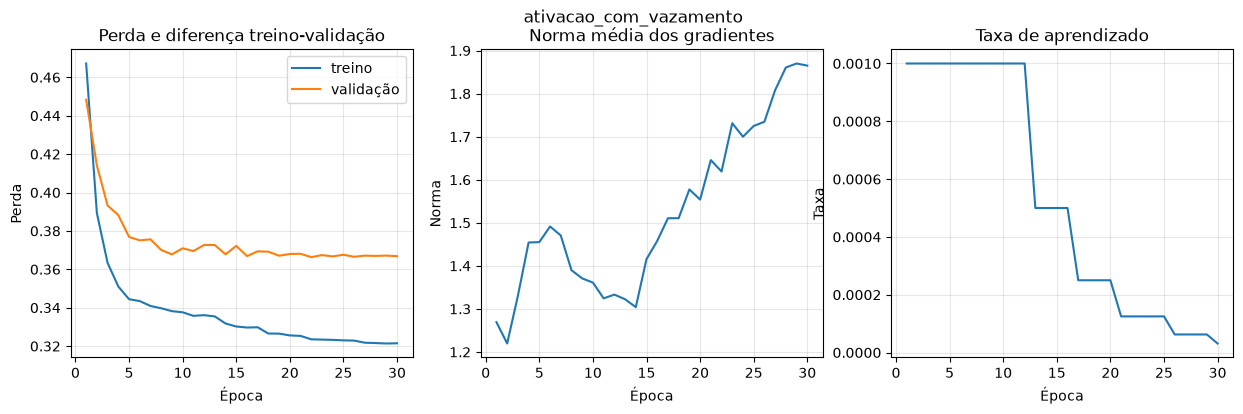

ativacao_com_vazamento → convergência: validação melhorou sem explosão dos gradientes


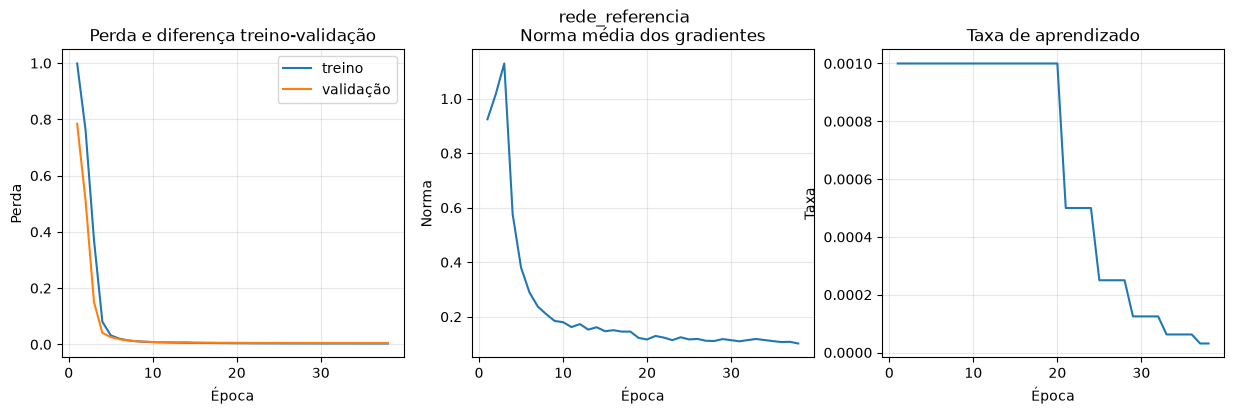

rede_referencia → convergência: validação melhorou sem explosão dos gradientes


In [29]:
# Exibe perda, norma dos gradientes e taxa de aprendizado usando o histórico real.
def plotar_historico(registro_experimento, titulo):
    # Historico em memoria serve como fonte unica da plotagem.
    historico_epocas = registro_experimento['historico_epocas']
    numeros_epocas = [registro_epoca['numero_epoca'] for registro_epoca in historico_epocas]
    perdas_treino = [registro_epoca['perda_treino'] for registro_epoca in historico_epocas]
    perdas_validacao = [registro_epoca['perda_validacao'] for registro_epoca in historico_epocas]
    normas_gradientes = [registro_epoca['norma_gradientes_media'] for registro_epoca in historico_epocas]
    taxas_aprendizado = [registro_epoca['taxa_aprendizado'] for registro_epoca in historico_epocas]
    # Tres paineis lado a lado.
    figura, eixos = grafico.subplots(1, 3, figsize=TAMANHO_FIGURA_DIAGNOSTICO)
    figura.suptitle(titulo)
    eixos[0].plot(numeros_epocas, perdas_treino, label='treino')
    eixos[0].plot(numeros_epocas, perdas_validacao, label='validação')
    eixos[0].set(title='Perda e diferença treino-validação', xlabel='Época', ylabel='Perda')
    # Identifica qual curva e treino e qual e validacao.
    eixos[0].legend()
    eixos[1].plot(numeros_epocas, normas_gradientes)
    eixos[1].set(title='Norma média dos gradientes', xlabel='Época', ylabel='Norma')
    eixos[2].plot(numeros_epocas, taxas_aprendizado)
    eixos[2].set(title='Taxa de aprendizado', xlabel='Época', ylabel='Taxa')
    for eixo in eixos:
        eixo.grid(alpha=TRANSPARENCIA_GRADE)
    grafico.show()


# Nomeia o fenômeno observado com critérios explícitos.
def diagnosticar_historico(historico_epocas):
    # Estado inicial para comparar com o final.
    primeiro_registro = historico_epocas[0]
    ultimo_registro = historico_epocas[-1]
    maior_norma_gradientes = max(
        registro_epoca['norma_gradientes_maxima'] for registro_epoca in historico_epocas
    )
    # Melhor perda de validacao observada em qualquer epoca.
    menor_perda_validacao = min(
        registro_epoca['perda_validacao'] for registro_epoca in historico_epocas
    )
    # Gap treino vs validacao na ultima epoca.
    diferenca_final = ultimo_registro['perda_validacao'] - ultimo_registro['perda_treino']
    if maior_norma_gradientes > LIMIAR_GRADIENTE_EXPLOSAO:
        # Norma dos gradientes explodiu em alguma epoca.
        return 'instabilidade: norma dos gradientes acima do limite definido'
    if ultimo_registro['perda_validacao'] > menor_perda_validacao * FATOR_PIORA_VALIDACAO and diferenca_final > 0:
        # Validacao piorou enquanto treino permaneceu menor.
        return 'sobreajuste: validação piorou enquanto treino permaneceu menor'
    if ultimo_registro['perda_validacao'] >= primeiro_registro['perda_validacao'] * FATOR_REDUCAO_MINIMA_PERDA:
        # Validacao quase nao melhorou.
        return 'subajuste ou convergência insuficiente: validação quase não melhorou'
    # Caso saudavel: validacao melhorou sem explosao.
    return 'convergência: validação melhorou sem explosão dos gradientes'


for melhor_experimento in (melhor_experimento_diabetes, melhor_experimento_imoveis):
    nome_experimento = melhor_experimento['configuracao']['nome_experimento']
    plotar_historico(melhor_experimento, nome_experimento)
    # Imprime o rotulo atribuido pelo classificador.
    print(nome_experimento, '→', diagnosticar_historico(melhor_experimento['historico_epocas']))

## 7. Teste final e reprodução

Somente agora os melhores modelos são avaliados no teste, que ficou guardado até aqui. O notebook também confere se o mesmo modelo produz o mesmo resultado quando recebe os mesmos dados.

### Bloco: carregar modelo a partir do checkpoint

**O que faz.** Recria uma rede a partir de um arquivo salvo durante o treinamento, sem precisar treiná-la novamente.

**Como faz.** O arquivo salvo guarda os pesos e a configuração da melhor versão da rede. A função lê essas informações, monta novamente a rede e a coloca no modo de avaliação, em que ela apenas faz previsões.


In [30]:
# Reconstrói um modelo usando apenas configuração e dicionário de estado persistidos.
def carregar_modelo_checkpoint(registro_experimento, informacoes_problema):
    conteudo_checkpoint = torch.load(
        registro_experimento['caminho_checkpoint'],
        map_location=DISPOSITIVO,
        # Necessario porque o checkpoint guarda mais do que apenas pesos.
        weights_only=False,
    )
    configuracao = conteudo_checkpoint['configuracao']
    modelo = PerceptronMulticamadas(
        informacoes_problema['quantidade_entradas'],
        QUANTIDADE_SAIDAS,
        configuracao['tipo_ativacao'],
        configuracao['usar_normalizacao_lote'],
        configuracao['taxa_descarte'],
        configuracao['tipo_inicializacao'],
    ).to(DISPOSITIVO)
    # Restaura os pesos originais a partir do snapshot.
    modelo.load_state_dict(conteudo_checkpoint['dicionario_estado_modelo'])
    # Coloca o modelo em modo de inferencia.
    modelo.eval()
    return modelo, conteudo_checkpoint


# Executa inferência determinística sem manter tensores desnecessários na GPU.
def realizar_predicoes(modelo, carregador_teste):
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    inicio_inferencia = perf_counter()
    rotulos_teste = []
    valores_saida_teste = []
    with torch.no_grad():
        for lote_caracteristicas, lote_rotulos in carregador_teste:
            valores_saida = modelo(lote_caracteristicas.to(DISPOSITIVO))
            rotulos_teste.append(lote_rotulos.cpu())
            valores_saida_teste.append(valores_saida.cpu())
    sincronizar_dispositivo_para_medicao(DISPOSITIVO)
    tempo_inferencia_segundos = perf_counter() - inicio_inferencia
    return (
        torch.vstack(rotulos_teste),
        torch.vstack(valores_saida_teste),
        tempo_inferencia_segundos,
    )

### Bloco: avaliação final dos modelos de referência

**O que faz.** Mede, no conjunto de teste, o desempenho dos modelos de referência usados para comparação.

**Como faz.** O modelo de diabetes e o modelo de imóveis fazem previsões para os dados de teste. Em seguida, o notebook calcula as mesmas métricas usadas para avaliar as redes neurais, permitindo uma comparação justa.


In [31]:
# Avalia as referências no teste somente depois da seleção dos melhores experimentos.
valores_saida_referencia_diabetes = modelo_referencia_diabetes.decision_function(
    conjunto_diabetes['caracteristicas_teste']
)
metricas_referencia_diabetes = calcular_metricas_classificacao(
    conjunto_diabetes['rotulos_teste'], valores_saida_referencia_diabetes,
)
previsoes_referencia_imoveis = modelo_referencia_imoveis.predict(
    conjunto_imoveis['caracteristicas_teste']
)
metricas_referencia_imoveis = calcular_metricas_regressao(
    conjunto_imoveis['rotulos_teste'], previsoes_referencia_imoveis,
    conjunto_imoveis['normalizador_alvo'],
)
print('Referência Diabetes no teste:', metricas_referencia_diabetes)
print('Referência Imóveis no teste:', metricas_referencia_imoveis)

Referência Diabetes no teste: {'acuracia': 0.887255581750104, 'precisao': 0.4321319018404908, 'sensibilidade': 0.8860062893081762, 'media_harmonica_precisao_sensibilidade': 0.5809278350515464}
Referência Imóveis no teste: {'erro_absoluto_medio': 7944.107421875, 'raiz_erro_quadratico_medio': 9960.770251341008, 'coeficiente_determinacao': 0.9986109733581543}


### Bloco: avaliação final dos melhores modelos e teste de reprodução

**O que faz.** Carrega os melhores modelos de diabetes e imóveis, faz previsões no teste e calcula seus resultados finais. Também verifica se repetir uma previsão produz o mesmo resultado.

**Como faz.** O notebook abre os arquivos salvos, faz duas previsões seguidas com cada modelo e compara as saídas. Para diabetes, usa o ponto de corte escolhido na validação para transformar probabilidades em classes. Para imóveis, compara diretamente os preços previstos e reais.


In [32]:
# Avalia os dois vencedores e confirma a reprodução exata das previsões.
# Recupera o melhor modelo de diabetes e o snapshot.
modelo_diabetes, checkpoint_diabetes = carregar_modelo_checkpoint(
    melhor_experimento_diabetes,
    conjunto_diabetes,
)
# Predicao de teste do modelo de diabetes.
(
    rotulos_teste_diabetes,
    valores_saida_diabetes,
    tempo_inferencia_diabetes_segundos,
) = realizar_predicoes(
    modelo_diabetes,
    conjunto_diabetes['carregador_teste'],
)
print(f'Diabetes — inferência: {tempo_inferencia_diabetes_segundos:.3f} s')
# Segunda passada para verificar determinismo.
(
    rotulos_diabetes_repetidos,
    valores_saida_diabetes_repetidos,
    tempo_inferencia_diabetes_repetida_segundos,
) = realizar_predicoes(
    modelo_diabetes,
    conjunto_diabetes['carregador_teste'],
)
print(f'Diabetes — repetição da inferência: {tempo_inferencia_diabetes_repetida_segundos:.3f} s')
# Inferencia deve ser deterministica no modo eval.
assert torch.allclose(valores_saida_diabetes, valores_saida_diabetes_repetidos)
# Usa o limiar escolhido pela validacao e salvo no checkpoint.
metricas_teste_diabetes = calcular_metricas_classificacao(
    rotulos_teste_diabetes.numpy(),
    valores_saida_diabetes.numpy(),
    checkpoint_diabetes['limiar_decisao'],
)

# Recupera o melhor modelo de imoveis.
modelo_imoveis, checkpoint_imoveis = carregar_modelo_checkpoint(
    melhor_experimento_imoveis,
    conjunto_imoveis,
)
# Predicao de teste do modelo de imoveis.
(
    rotulos_teste_imoveis,
    previsoes_imoveis,
    tempo_inferencia_imoveis_segundos,
) = realizar_predicoes(
    modelo_imoveis,
    conjunto_imoveis['carregador_teste'],
)
print(f'Imóveis — inferência: {tempo_inferencia_imoveis_segundos:.3f} s')
(
    rotulos_imoveis_repetidos,
    previsoes_imoveis_repetidas,
    tempo_inferencia_imoveis_repetida_segundos,
) = realizar_predicoes(
    modelo_imoveis,
    conjunto_imoveis['carregador_teste'],
)
print(f'Imóveis — repetição da inferência: {tempo_inferencia_imoveis_repetida_segundos:.3f} s')
# Confirma determinismo tambem em regressao.
assert torch.allclose(previsoes_imoveis, previsoes_imoveis_repetidas)
# Calcula MAE/RMSE/R2 na escala monetaria original.
metricas_teste_imoveis = calcular_metricas_regressao(
    rotulos_teste_imoveis.numpy(),
    previsoes_imoveis.numpy(),
    conjunto_imoveis['normalizador_alvo'],
)

print('Diabetes — referência:', metricas_referencia_diabetes)
print('Diabetes — Perceptron Multicamadas:', metricas_teste_diabetes)
print('Imóveis — referência:', metricas_referencia_imoveis)
print('Imóveis — Perceptron Multicamadas:', metricas_teste_imoveis)

Diabetes — inferência: 1.172 s
Diabetes — repetição da inferência: 0.912 s
Imóveis — inferência: 0.005 s
Imóveis — repetição da inferência: 0.004 s
Diabetes — referência: {'acuracia': 0.887255581750104, 'precisao': 0.4321319018404908, 'sensibilidade': 0.8860062893081762, 'media_harmonica_precisao_sensibilidade': 0.5809278350515464}
Diabetes — Perceptron Multicamadas: {'acuracia': 0.9708084870336985, 'precisao': 0.9364102564102564, 'sensibilidade': 0.7177672955974843, 'media_harmonica_precisao_sensibilidade': 0.8126390743213173}
Imóveis — referência: {'erro_absoluto_medio': 7944.107421875, 'raiz_erro_quadratico_medio': 9960.770251341008, 'coeficiente_determinacao': 0.9986109733581543}
Imóveis — Perceptron Multicamadas: {'erro_absoluto_medio': 13819.7021484375, 'raiz_erro_quadratico_medio': 17568.63295763219, 'coeficiente_determinacao': 0.9956788420677185}


### Bloco: matriz de confusão do classificador

**O que faz.** Mostra uma matriz de confusão, uma tabela que resume os acertos e erros do melhor modelo de diabetes no teste.

**Como faz.** O código transforma as saídas da rede em probabilidades e aplica o ponto de corte escolhido. Depois, conta quantos casos com e sem diabetes foram classificados corretamente ou incorretamente e mostra esses números em uma tabela visual.


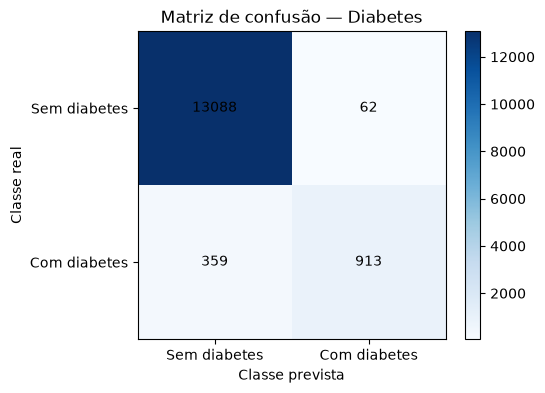

Falsos negativos: 359
Falsos positivos: 62
Hipótese: desbalanceamento e sobreposição dos indicadores clínicos contribuem para os erros.


In [33]:
# Apresenta os tipos de erro do classificador para apoiar uma hipótese sobre o domínio.
# Protege contra overflow no exp de valores muito negativos.
valores_limitados = numpy.clip(
    valores_saida_diabetes.numpy().ravel(),
    -LIMITE_ABSOLUTO_LOGITO,
    LIMITE_ABSOLUTO_LOGITO,
)
# Sigmoide numerica para converter logitos em probabilidade.
probabilidades_diabetes = 1 / (1 + numpy.exp(-valores_limitados))
classes_previstas_diabetes = (
    probabilidades_diabetes >= checkpoint_diabetes['limiar_decisao']
).astype(int)
# Conta cruzamentos entre classes reais e previstas.
matriz_confusao_diabetes = confusion_matrix(
    rotulos_teste_diabetes.numpy().ravel().astype(int),
    classes_previstas_diabetes,
)
grafico.figure(figsize=TAMANHO_FIGURA_MATRIZ)
# Mapa de calor: tons mais escuros indicam mais exemplos.
grafico.imshow(matriz_confusao_diabetes, cmap='Blues')
grafico.xticks([0, 1], ['Sem diabetes', 'Com diabetes'])
grafico.yticks([0, 1], ['Sem diabetes', 'Com diabetes'])
grafico.xlabel('Classe prevista')
grafico.ylabel('Classe real')
# Titulo do grafico para relatorio.
grafico.title('Matriz de confusão — Diabetes')
for linha in range(QUANTIDADE_CLASSES_DIABETES):
    for coluna in range(QUANTIDADE_CLASSES_DIABETES):
        grafico.text(coluna, linha, matriz_confusao_diabetes[linha, coluna], ha='center', va='center')
grafico.colorbar()
grafico.show()
# Linha 1, coluna 0: casos reais positivos classificados como negativos.
print(f'Falsos negativos: {matriz_confusao_diabetes[1, 0]}')
# Linha 0, coluna 1: casos reais negativos classificados como positivos.
print(f'Falsos positivos: {matriz_confusao_diabetes[0, 1]}')
print('Hipótese: desbalanceamento e sobreposição dos indicadores clínicos contribuem para os erros.')

### Bloco: inspeção visual da regressão

**O que faz.** Mostra, na unidade monetária original, quão próximos os preços previstos ficaram dos preços reais.

**Como faz.** O primeiro gráfico compara cada preço real com o preço previsto; pontos próximos da linha vermelha representam previsões melhores. O segundo mostra a distribuição dos erros, calculados como preço real menos preço previsto.


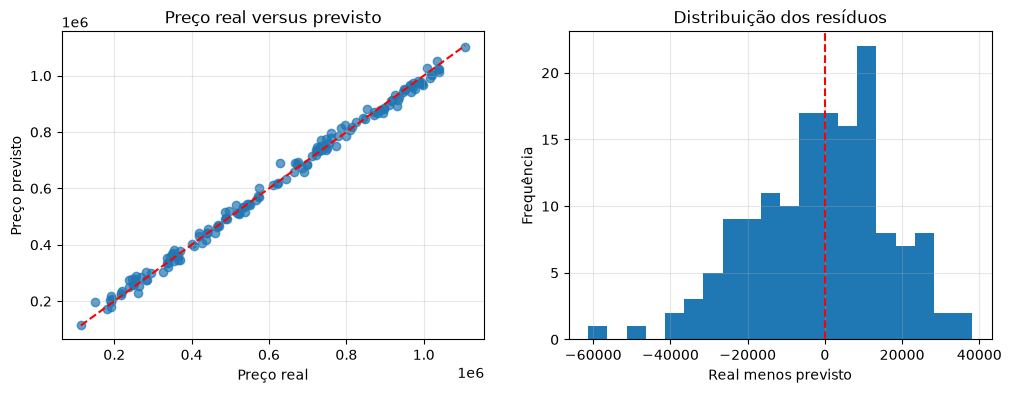

In [34]:
# Inspeciona qualidade e distribuição dos erros da regressão na unidade monetária original.
# Devolve os precos para a escala monetaria original.
precos_reais = conjunto_imoveis['normalizador_alvo'].inverse_transform(
    rotulos_teste_imoveis.numpy()
).ravel()
precos_previstos = conjunto_imoveis['normalizador_alvo'].inverse_transform(
    previsoes_imoveis.numpy()
).ravel()
# Res = observado - previsto. Media proxima de zero indica ausencia de vies.
residuos_precos = precos_reais - precos_previstos
# Dois graficos lado a lado para inspecao visual.
figura, eixos = grafico.subplots(1, 2, figsize=TAMANHO_FIGURA_REGRESSAO)
eixos[0].scatter(precos_reais, precos_previstos, alpha=0.7)
limite_inferior = min(precos_reais.min(), precos_previstos.min())
limite_superior = max(precos_reais.max(), precos_previstos.max())
# Linha vermelha y = x: referencia de perfeito ajuste.
eixos[0].plot([limite_inferior, limite_superior], [limite_inferior, limite_superior], 'r--')
# Dispersao: pontos sobre a linha significam acerto.
eixos[0].set(title='Preço real versus previsto', xlabel='Preço real', ylabel='Preço previsto')
# Histograma dos residuos em bins definidos por constante.
eixos[1].hist(residuos_precos, bins=QUANTIDADE_INTERVALOS_HISTOGRAMA)
# Linha vermelha em zero: ajuda a ver simetria dos residuos.
eixos[1].axvline(0, color='red', linestyle='--')
eixos[1].set(title='Distribuição dos resíduos', xlabel='Real menos previsto', ylabel='Frequência')
for eixo in eixos:
    eixo.grid(alpha=TRANSPARENCIA_GRADE)
grafico.show()

## Conclusão

Após a execução, registre aqui: a comparação com os modelos de referência, as configurações vencedoras, o fenômeno observado nas curvas e um problema identificado, a hipótese sobre sua causa, a correção aplicada e o efeito medido.

Neste experimento, a regressão linear superou a rede no conjunto de teste: obteve RMSE de aproximadamente 9.960,77, contra 21.470,90 da rede. Esse resultado sugere que, para estes dados e hiperparâmetros, a relação entre os atributos e o preço é bem capturada por um modelo linear; configurações adicionais da rede poderiam ser investigadas antes de atribuir a diferença à variância.